In [1]:
# Setup imports and initial dataset load
import pandas as pd
import matplotlib.pyplot as plt

csv_df = pd.read_csv('public2024.csv')
print("Loaded public2024.csv with", csv_df.shape, "rows/cols")


Loaded public2024.csv with (12295, 751) rows/cols


C:\Users\barto\AppData\Local\Temp\ipykernel_12004\3411277954.py:5: DtypeWarning: Columns (0: L0C, 1: CG1A, 2: CG9, 3: D41_b, 4: GE1C, 5: GE1E_a, 6: GE1E_b, 7: GE1E_c, 8: GE1E_d, 9: GE1E_e, 10: GH12A, 11: R5C_a, 12: R5C_b, 13: R5C_c, 14: R5C_d, 15: BK48, 16: BK50, 17: BK51, 18: BK52_a, 19: BK52_b, 20: BK52_c, 21: BK52_d, 22: BK52_e, 23: BK52_f, 24: BK52_g, 25: BK52_h, 26: A8_b, 27: A8_c, 28: A8_d, 29: A8_e, 30: SL4, 31: SL13, 32: K14_a, 33: K14_b, 34: K15_a, 35: K15_b, 36: K15_c, 37: K15_d, 38: K15_e, 39: INF3_g, 40: ppfs0001, 41: ppfs0596, 42: ppfs1482, 43: pphi0001) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_df = pd.read_csv('public2024.csv')


BNPL1                                          No  Yes
educ_4cat                                             
Bachelor's degree or more                    4737  545
High school degree or GED                    2004  316
Less than a high school degree                466   92
Some college/technical or associates degree  3418  717
BNPL1                                  No        Yes
educ_4cat                                           
Bachelor's degree or more       89.681939  10.318061
High school degree or GED       86.379310  13.620690
Less than a high school degree  83.512545  16.487455
Associates or Dropouts          82.660218  17.339782


C:\Users\Ramesh\AppData\Local\Temp\ipykernel_6200\3592664955.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,


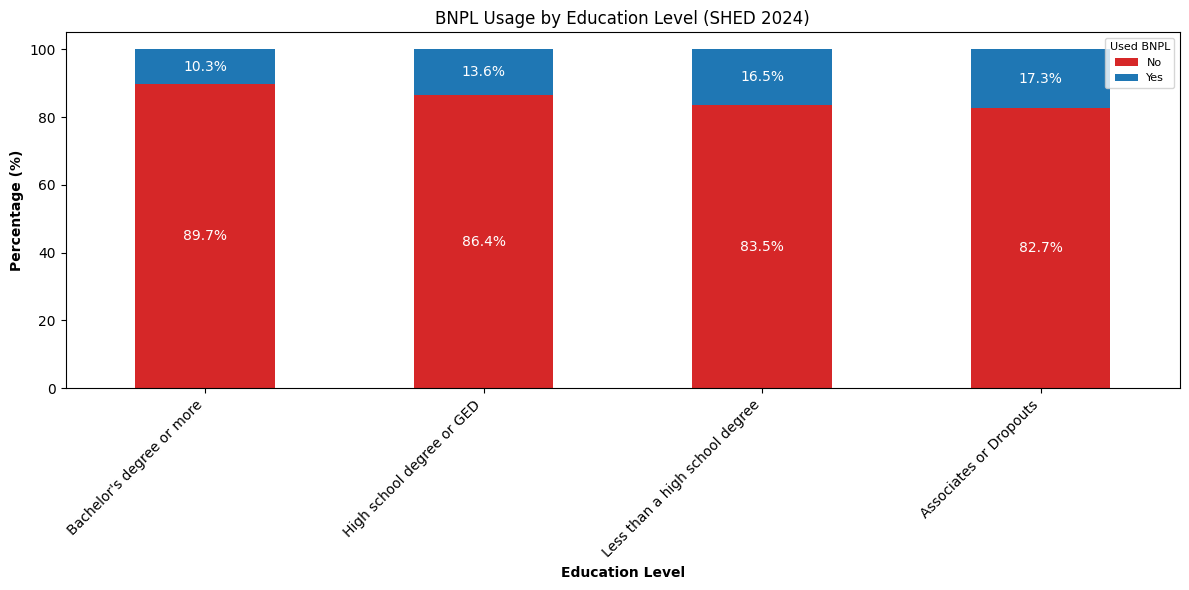

In [18]:
# calculate usage rates by education category

if 'csv_df' not in globals():
    csv_df = pd.read_csv('public2024.csv')
    print("Loaded public2024.csv with", csv_df.shape, "rows/cols")

group = csv_df.groupby(['educ_4cat','BNPL1']).size().unstack(fill_value=0)
# compute percentages within each education
grp_pct = group.div(group.sum(axis=1), axis=0) * 100

# rename index for cleaner labels
grp_pct.index = grp_pct.index.str.replace('Some college/technical or associates degree', 'Associates or Dropouts')

print(group)
print(grp_pct)

grp_pct.plot(kind='bar', stacked=True, figsize=(12,6), color=['#d62728','#1f77b4'])
plt.title('BNPL Usage by Education Level (SHED 2024)')
plt.ylabel('Percentage (%)', fontweight='bold')
plt.xlabel('Education Level', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Used BNPL', loc='upper right', fontsize=8, title_fontsize=8)

# add labels
for i, edu in enumerate(grp_pct.index):
    for j, val in enumerate(grp_pct.loc[edu]):
        plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,
                 f"{val:.1f}%", ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('bnpl_by_education.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# create a tidy dataframe suitable for export
# use the count (group) and percentage (grp_pct) tables
count_df = group.reset_index().melt(id_vars=['educ_4cat'],
                                     value_vars=['No','Yes'],
                                     var_name='Used_BNPL',
                                     value_name='count')
pct_df = grp_pct.reset_index().melt(id_vars=['educ_4cat'],
                                     var_name='Used_BNPL',
                                     value_name='percent')
export_df = count_df.merge(pct_df, on=['educ_4cat','Used_BNPL'])

# save to csv for Tableau
export_df.to_csv('bnpl_by_education.csv', index=False)
print('exported', export_df.shape, 'rows to bnpl_by_education.csv')

export_df.head()

exported (6, 4) rows to bnpl_by_education.csv


,educ_4cat,Used_BNPL,count,percent
0,Bachelor's degree or more,No,4737,89.681939
1,High school degree or GED,No,2004,86.379310
2,Less than a high school degree,No,466,83.512545
3,Bachelor's degree or more,Yes,545,10.318061
4,High school degree or GED,Yes,316,13.620690


In [20]:
# load the public2024 dataset and inspect
import pandas as pd

csv_df = pd.read_csv('public2024.csv')
print(csv_df.info())

display(csv_df.head())

# check relevant columns for education and BNPL usage
print("Columns:", csv_df.columns.tolist())

# look for specific columns with keywords
educ_cols = [c for c in csv_df.columns if 'educ' in c.lower()]
bnpl_cols = [c for c in csv_df.columns if 'bnpl' in c.lower() or 'buy now' in c.lower()]
print('education-related columns:', educ_cols)
print('bnpl-related columns:', bnpl_cols)


C:\Users\Ramesh\AppData\Local\Temp\ipykernel_6200\97090170.py:4: DtypeWarning: Columns (15,41,50,100,115,117,118,119,120,121,132,151,152,153,154,182,185,186,187,188,189,190,191,192,193,194,208,209,210,211,240,250,260,261,262,263,264,265,266,301,390,391,392,394) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_df = pd.read_csv('public2024.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12295 entries, 0 to 12294
Columns: 751 entries, shedid to year
dtypes: float64(22), int64(355), object(374)
memory usage: 70.4+ MB
None


,shedid,duration,weight,weight_pop,panel_weight,panel_weight_pop,xlaptop,L0_a,L0_b,L0_c,...,E4_f_iflag,CH2A_iflag,race_5cat,inc_4cat_50k,educ_4cat,pay_casheqv,atleast_okay,control,ED0_orig,year
0,202203873,1333,0.6149,12971.9817,1.2153,78509.7641,No,No,No,No,...,0,0,White,"$25,000–$49,999",Bachelor's degree or more,Yes,Yes,Public,Master’s degree,2024
1,202204577,975,0.8301,17511.2242,NaN,NaN,No,No,No,No,...,0,0,White,"$100,000 or more",Bachelor's degree or more,Yes,Yes,Public,Master’s degree,2024
2,201800189,2146,0.4447,9381.0980,0.8061,52078.4957,No,No,No,No,...,0,0,White,"$50,000–$99,999",Bachelor's degree or more,Yes,Yes,NaN,Bachelor’s degree,2024
3,202406204,1214,0.8333,17580.0326,NaN,NaN,No,Yes,No,No,...,0,0,White,"$50,000–$99,999",High school degree or GED,Yes,Yes,NaN,High school degree or GED,2024
4,202200780,1168,0.9064,19121.3763,NaN,NaN,No,Yes,No,No,...,0,0,White,"$50,000–$99,999",Some college/technical or associates degree,Yes,Yes,Public,Associate degree,2024


Columns: ['shedid', 'duration', 'weight', 'weight_pop', 'panel_weight', 'panel_weight_pop', 'xlaptop', 'L0_a', 'L0_b', 'L0_c', 'L0_d', 'L0_e', 'L0B_a', 'L0B_b', 'L0B_c', 'L0C', 'L0E', 'B2', 'B3', 'B3A_a', 'B3A_b', 'B3A_c', 'B3A_d', 'B3A_e', 'B3B_a', 'B3B_b', 'B3B_c', 'B3B_d', 'B3B_e', 'B7_a', 'B7_b', 'X11_none', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'X13', 'CG0', 'CG1A', 'CG2', 'CG7_a', 'CG7_b', 'CG7_c', 'CG7_d', 'CG7_e', 'CG7_f', 'CG7_g', 'CG9', 'CG8', 'CG3', 'CG4', 'CG5_a', 'CG5_b', 'CG5_c', 'CG5_d', 'CG5_e', 'CG5_f', 'CG6', 'D1A', 'D4', 'D48', 'D3B', 'D1E', 'D22_a', 'D22_b', 'D22_c', 'D22_d', 'D22_e', 'D22_f', 'D22_g', 'D22_h', 'D22_i', 'D3A', 'D3E', 'D28_a', 'D28_b', 'D30', 'D47', 'D34A', 'D36B', 'D44_f', 'D44_a', 'D44_b', 'D44_c', 'D44_d', 'D44_e', 'D37A', 'D38_a', 'D38_b', 'D38_c', 'D38_d', 'D38_f', 'D39', 'D1B', 'D5', 'D49', 'D41_a', 'D41_b', 'D41_c', 'D41_d', 'D41_e', 'D41_f', 'D41_g', 'D41_h', 'D41_i', 'GE2A', 'GE12_a', 'GE12_b', 'GE12_c', 'GE2B', 'GE1

In [21]:
# further inspect relevant columns

educ_cols = [c for c in csv_df.columns if 'educ' in c.lower()]
bnpl_cols = [c for c in csv_df.columns if 'bnpl' in c.lower() or 'buy now' in c.lower()]

print(f"Found {len(educ_cols)} education columns")
for c in educ_cols[:30]:
    print(c)

print(f"\nFound {len(bnpl_cols)} BNPL columns")
for c in bnpl_cols[:30]:
    print(c)


Found 3 education columns
ppeduc5
ppeducat
educ_4cat

Found 20 BNPL columns
BNPL1
BNPL3
BNPL3A
BNPL4_a
BNPL4_b
BNPL4_c
BNPL4_d
BNPL4_e
BNPL4_f
BNPL4_g
BNPL1_iflag
BNPL3_iflag
BNPL3A_iflag
BNPL4_a_iflag
BNPL4_b_iflag
BNPL4_c_iflag
BNPL4_d_iflag
BNPL4_e_iflag
BNPL4_f_iflag
BNPL4_g_iflag


In [22]:
# examine unique values for education columns and BNPL1
for col in ['ppeduc5','ppeducat','educ_4cat']:
    print(col, csv_df[col].value_counts(dropna=False).head())
    print('---')

# look at BNPL1 distribution
print('BNPL1 values:', csv_df['BNPL1'].value_counts(dropna=False))

# sample rows where BNPL1 is not null and education not null
csv_df.loc[csv_df['BNPL1'].notna(), ['ppeduc5','ppeducat','educ_4cat','BNPL1']].head(10)


ppeduc5 ppeduc5
Some college or Associate's degree                                  3429
Bachelor's degree                                                   2902
High school graduate (high school diploma or the equivalent GED)    2857
Master’s degree or higher                                           2316
No high school diploma or GED                                        791
Name: count, dtype: int64
---
ppeducat ppeducat
Bachelor's degree or higher                                         5218
Some college or Associate's degree                                  3429
High school graduate (high school diploma or the equivalent GED)    2857
No high school diploma or GED                                        791
Name: count, dtype: int64
---
educ_4cat educ_4cat
Bachelor's degree or more                      5282
Some college/technical or associates degree    4135
High school degree or GED                      2320
Less than a high school degree                  558
Name: count, dtype: i

,ppeduc5,ppeducat,educ_4cat,BNPL1
0,Master’s degree or higher,Bachelor's degree or higher,Bachelor's degree or more,No
1,Master’s degree or higher,Bachelor's degree or higher,Bachelor's degree or more,No
2,Bachelor's degree,Bachelor's degree or higher,Bachelor's degree or more,No
3,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,High school degree or GED,No
4,Some college or Associate's degree,Some college or Associate's degree,Some college/technical or associates degree,No
5,Bachelor's degree,Bachelor's degree or higher,Bachelor's degree or more,No
6,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,High school degree or GED,No
7,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,Some college/technical or associates degree,Yes
8,High school graduate (high school diploma or t...,High school graduate (high school diploma or t...,High school degree or GED,No
9,Bachelor's degree,Bachelor's degree or higher,Bachelor's degree or more,No


BNPL1                                          No  Yes
educ_4cat                                             
Bachelor's degree or more                    4737  545
High school degree or GED                    2004  316
Less than a high school degree                466   92
Some college/technical or associates degree  3418  717
BNPL1                                               No        Yes
educ_4cat                                                        
Bachelor's degree or more                    89.681939  10.318061
High school degree or GED                    86.379310  13.620690
Less than a high school degree               83.512545  16.487455
Some college/technical or associates degree  82.660218  17.339782


C:\Users\Ramesh\AppData\Local\Temp\ipykernel_6200\2351626043.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,


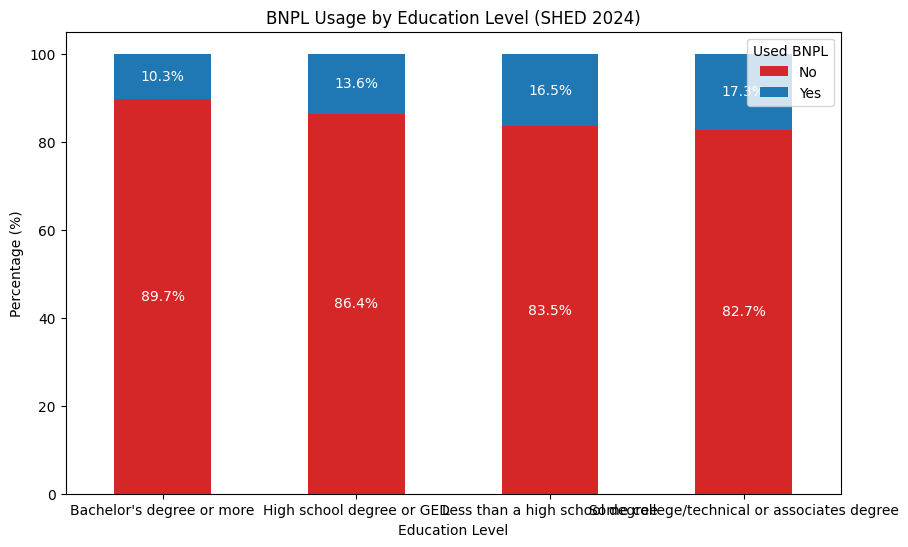

In [23]:
# calculate usage rates by education category

group = csv_df.groupby(['educ_4cat','BNPL1']).size().unstack(fill_value=0)
# compute percentages within each education
grp_pct = group.div(group.sum(axis=1), axis=0) * 100

print(group)
print(grp_pct)

grp_pct.plot(kind='bar', stacked=True, figsize=(10,6), color=['#d62728','#1f77b4'])
plt.title('BNPL Usage by Education Level (SHED 2024)')
plt.ylabel('Percentage (%)')
plt.xlabel('Education Level')
plt.xticks(rotation=0)
plt.legend(title='Used BNPL', loc='upper right')

# add labels
for i, edu in enumerate(grp_pct.index):
    for j, val in enumerate(grp_pct.loc[edu]):
        plt.text(i, grp_pct.loc[edu].cumsum()[j] - val/2,
                 f"{val:.1f}%", ha='center', va='center', color='white', fontsize=10)

plt.show()


In [2]:
# Search for credit card and BNPL related columns
import pandas as pd

csv_df = pd.read_csv('public2024.csv')

# Find all columns
all_cols = csv_df.columns.tolist()
print(f"Total columns: {len(all_cols)}\n")

# Search for credit card related columns
cc_cols = [c for c in all_cols if 'credit' in c.lower() or 'card' in c.lower() or 'denied' in c.lower() or 'turned' in c.lower() or 'deny' in c.lower()]
print("Credit card related columns:")
for c in cc_cols:
    print(f"  {c}")

# Search for BNPL columns
bnpl_cols = [c for c in all_cols if 'bnpl' in c.lower() or 'buy' in c.lower()]
print("\nBNPL related columns:")
for c in bnpl_cols:
    print(f"  {c}")

# Show first few columns to get sense of data
print("\nFirst 20 columns:")
for i, c in enumerate(all_cols[:20]):
    print(f"  {i}: {c}")

Total columns: 751

Credit card related columns:

BNPL related columns:
  BNPL1
  BNPL3
  BNPL3A
  BNPL4_a
  BNPL4_b
  BNPL4_c
  BNPL4_d
  BNPL4_e
  BNPL4_f
  BNPL4_g
  BNPL1_iflag
  BNPL3_iflag
  BNPL3A_iflag
  BNPL4_a_iflag
  BNPL4_b_iflag
  BNPL4_c_iflag
  BNPL4_d_iflag
  BNPL4_e_iflag
  BNPL4_f_iflag
  BNPL4_g_iflag

First 20 columns:
  0: shedid
  1: duration
  2: weight
  3: weight_pop
  4: panel_weight
  5: panel_weight_pop
  6: xlaptop
  7: L0_a
  8: L0_b
  9: L0_c
  10: L0_d
  11: L0_e
  12: L0B_a
  13: L0B_b
  14: L0B_c
  15: L0C
  16: L0E
  17: B2
  18: B3
  19: B3A_a


C:\Users\barto\AppData\Local\Temp\ipykernel_12004\1538798318.py:4: DtypeWarning: Columns (0: L0C, 1: CG1A, 2: CG9, 3: D41_b, 4: GE1C, 5: GE1E_a, 6: GE1E_b, 7: GE1E_c, 8: GE1E_d, 9: GE1E_e, 10: GH12A, 11: R5C_a, 12: R5C_b, 13: R5C_c, 14: R5C_d, 15: BK48, 16: BK50, 17: BK51, 18: BK52_a, 19: BK52_b, 20: BK52_c, 21: BK52_d, 22: BK52_e, 23: BK52_f, 24: BK52_g, 25: BK52_h, 26: A8_b, 27: A8_c, 28: A8_d, 29: A8_e, 30: SL4, 31: SL13, 32: K14_a, 33: K14_b, 34: K15_a, 35: K15_b, 36: K15_c, 37: K15_d, 38: K15_e, 39: INF3_g, 40: ppfs0001, 41: ppfs0596, 42: ppfs1482, 43: pphi0001) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_df = pd.read_csv('public2024.csv')


In [3]:
# Search more broadly for columns - look for patterns like "applied", "denied", "rejected", "turned down"
# Based on SHED 2024 codebook, credit card denial questions use codes like CG, CC, etc

broader_search = ['applied', 'denied', 'rejected', 'approved', 'declined', 'turned', 
                  'credit', 'application', 'loan', 'mortgage', 'attempted']

relevant_cols = []
for col in all_cols:
    col_lower = col.lower()
    for term in broader_search:
        if term in col_lower:
            relevant_cols.append(col)
            break

print("Potentially relevant columns (broader search):")
for c in relevant_cols:
    print(f"  {c}")

# Also look at column prefixes - these often indicate question grouping
prefixes = set()
for col in all_cols:
    # Extract letters before numbers
    prefix = ''.join(c for c in col.split('_')[0] if not c.isdigit())[:4]
    if len(prefix) >= 2:
        prefixes.add(prefix)

print(f"\nUnique column prefixes ({len(prefixes)} total):")
sorted_prefixes = sorted(prefixes)
for i in range(0, len(sorted_prefixes), 10):
    print(f"  {' '.join(sorted_prefixes[i:i+10])}")

Potentially relevant columns (broader search):

Unique column prefixes (85 total):
  AB BA BB BK BKA BKB BNPL CA CG CGA
  CHA CP DA DB DC DE DG DI DOV EA
  EB ED EDB EDD EF EFC FD GE GEA GEB
  GEC GED GEE GH GHA INF KA KB LB LC
  LE ND RB RC SL SLA Stat UNIO atle cont
  dura educ fiel inc ind pane pay ppag ppcm pped
  ppem ppet ppfs ppge pph pphd pphh pphi ppho ppin
  ppki ppma ppms ppp pppa pppd ppra ppre ppst ppto
  race shed weig xlap year


In [4]:
# Focus on likely credit card columns - CG prefix
cg_cols = [c for c in all_cols if c.startswith('CG')]
print(f"CG columns ({len(cg_cols)}):")
for c in cg_cols:
    print(f"  {c}")

# Show sample values for CG columns
print("\n\nSample values for CG columns:")
for c in cg_cols[:10]:
    print(f"\n{c}:")
    print(csv_df[c].value_counts(dropna=False).head(10))

CG columns (42):
  CG0
  CG1A
  CG2
  CG7_a
  CG7_b
  CG7_c
  CG7_d
  CG7_e
  CG7_f
  CG7_g
  CG9
  CG8
  CG3
  CG4
  CG5_a
  CG5_b
  CG5_c
  CG5_d
  CG5_e
  CG5_f
  CG6
  CG0_iflag
  CG1A_iflag
  CG2_iflag
  CG7_a_iflag
  CG7_b_iflag
  CG7_c_iflag
  CG7_d_iflag
  CG7_e_iflag
  CG7_f_iflag
  CG7_g_iflag
  CG9_iflag
  CG8_iflag
  CG3_iflag
  CG4_iflag
  CG5_a_iflag
  CG5_b_iflag
  CG5_c_iflag
  CG5_d_iflag
  CG5_e_iflag
  CG5_f_iflag
  CG6_iflag


Sample values for CG columns:

CG0:
CG0
NaN    10262
No      1550
Yes      483
Name: count, dtype: int64

CG1A:
CG1A
NaN                 11814
40 hours or more      158
20 to 39 hours        120
10 to 19 hours        109
1 to 9 hours           94
Name: count, dtype: int64

CG2:
CG2
NaN      11812
300.0       32
200.0       29
150.0       25
500.0       21
250.0       21
100.0       20
450.0       16
350.0       15
400.0       14
Name: count, dtype: int64

CG7_a:
CG7_a
NaN    10262
No      1404
Yes      629
Name: count, dtype: int64

CG7_b:
CG7

In [5]:
# Continue checking remaining CG columns
print("Remaining CG columns values:")
for c in ['CG3', 'CG4', 'CG5_a', 'CG6', 'CG8', 'CG9']:
    print(f"\n{c}:")
    print(csv_df[c].value_counts(dropna=False).head(8))

# CG0 seems to be the main one - let's examine it more
print("\n\n=== MAIN QUESTION CG0 ===")
print(csv_df['CG0'].value_counts(dropna=False))
print(f"Total respondents: {len(csv_df)}")
print(f"Answered (not NaN): {csv_df['CG0'].notna().sum()}")

# Now check BNPL1 to see what it contains
print("\n\n=== BNPL Usage (BNPL1) ===")
print(csv_df['BNPL1'].value_counts(dropna=False))

Remaining CG columns values:

CG3:
CG3
NaN                                                                  10551
My spouse/partner and I equally share caretaking responsibilities      831
I am usually the primary caretaker                                     580
My spouse/partner is usually the primary caretaker                     333
Name: count, dtype: int64

CG4:
CG4
No     10156
Yes     2139
Name: count, dtype: int64

CG5_a:
CG5_a
NaN    10156
No      1120
Yes     1019
Name: count, dtype: int64

CG6:
CG6
NaN                         10156
Daily                         742
Several days per week         577
Several days per month        576
Once per month                155
Less than once per month       89
Name: count, dtype: int64

CG8:
CG8
NaN                 11363
1 to 9 hours          547
10 to 19 hours        196
20 to 39 hours        118
40 hours or more       71
Name: count, dtype: int64

CG9:
CG9
NaN    12162
Yes      103
No        30
Name: count, dtype: int64


=== MAIN QU

In [6]:
# Create cross-tabulation of Credit Card Denial (CG0) vs BNPL Usage (BNPL1)
# Filter to only rows where both CG0 and BNPL1 have data (not NaN)

df_analysis = csv_df[['CG0', 'BNPL1']].copy()
df_analysis = df_analysis.dropna()

print(f"Respondents with both CG0 and BNPL1 data: {len(df_analysis)}")

# Create cross-tabulation with counts
crosstab_counts = pd.crosstab(df_analysis['CG0'], df_analysis['BNPL1'], margins=False)
print("\n=== Credit Card Denial vs BNPL Usage (Counts) ===")
print(crosstab_counts)

# Create cross-tabulation with percentages
crosstab_pct = pd.crosstab(df_analysis['CG0'], df_analysis['BNPL1'], normalize='index') * 100
print("\n=== Credit Card Denial vs BNPL Usage (Row Percentages) ===")
print(crosstab_pct.round(2))

# Create tidy dataframe for export to Tableau
tidy_data = []
for cc_status in df_analysis['CG0'].unique():
    for bnpl_status in df_analysis['BNPL1'].unique():
        count = len(df_analysis[(df_analysis['CG0'] == cc_status) & (df_analysis['BNPL1'] == bnpl_status)])
        subset = df_analysis[(df_analysis['CG0'] == cc_status)]
        pct = (count / len(subset) * 100) if len(subset) > 0 else 0
        
        tidy_data.append({
            'Credit_Card_Denial': cc_status,
            'BNPL_Usage': bnpl_status,
            'Count': count,
            'Percentage': round(pct, 2)
        })

export_df = pd.DataFrame(tidy_data)
export_df = export_df.sort_values(['Credit_Card_Denial', 'BNPL_Usage'])

print("\n=== Tidy Data for Tableau ===")
print(export_df)

# Save to CSV
export_df.to_csv('credit_card_denial_vs_bnpl.csv', index=False)
print("\nExported to: credit_card_denial_vs_bnpl.csv")

Respondents with both CG0 and BNPL1 data: 2033

=== Credit Card Denial vs BNPL Usage (Counts) ===
BNPL1    No  Yes
CG0             
No     1257  293
Yes     408   75

=== Credit Card Denial vs BNPL Usage (Row Percentages) ===
BNPL1     No    Yes
CG0                
No     81.10  18.90
Yes    84.47  15.53

=== Tidy Data for Tableau ===
  Credit_Card_Denial BNPL_Usage  Count  Percentage
0                 No         No   1257       81.10
1                 No        Yes    293       18.90
2                Yes         No    408       84.47
3                Yes        Yes     75       15.53

Exported to: credit_card_denial_vs_bnpl.csv


Visualization saved to: credit_card_denial_vs_bnpl.png


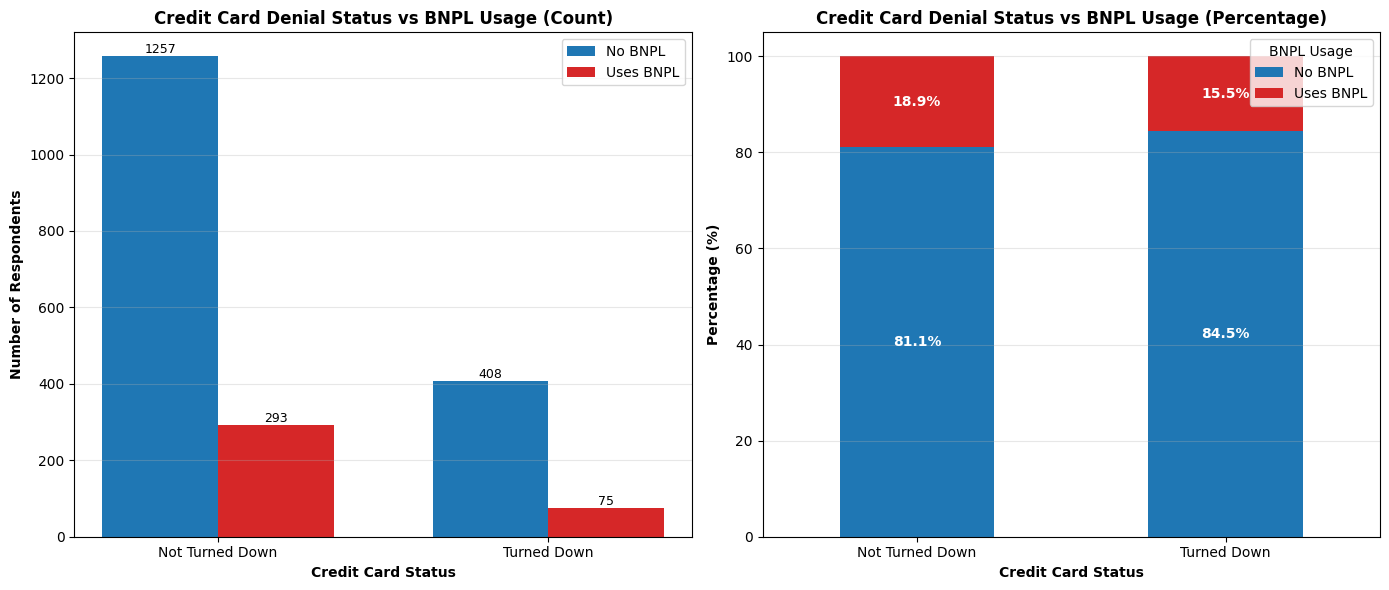


=== SUMMARY STATISTICS ===
Total respondents with both measures: 2033

Not turned down for credit card: 1550 (76.2%)
  - Use BNPL: 293 (18.9%)

Turned down for credit card: 483 (23.8%)
  - Use BNPL: 75 (15.5%)


In [7]:
# Create visualization showing Credit Card Denial vs BNPL Usage
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Grouped bar chart with counts
ax1 = axes[0]
x = np.arange(len(crosstab_counts.index))
width = 0.35

bars1 = ax1.bar(x - width/2, crosstab_counts['No'], width, label='No BNPL', color='#1f77b4')
bars2 = ax1.bar(x + width/2, crosstab_counts['Yes'], width, label='Uses BNPL', color='#d62728')

ax1.set_xlabel('Credit Card Status', fontweight='bold')
ax1.set_ylabel('Number of Respondents', fontweight='bold')
ax1.set_title('Credit Card Denial Status vs BNPL Usage (Count)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Not Turned Down', 'Turned Down'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

# Chart 2: Stacked percentage bar chart
ax2 = axes[1]
crosstab_pct.plot(kind='bar', stacked=True, ax=ax2, color=['#1f77b4', '#d62728'])
ax2.set_xlabel('Credit Card Status', fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontweight='bold')
ax2.set_title('Credit Card Denial Status vs BNPL Usage (Percentage)', fontweight='bold')
ax2.set_xticklabels(['Not Turned Down', 'Turned Down'], rotation=0)
ax2.legend(title='BNPL Usage', labels=['No BNPL', 'Uses BNPL'], loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, idx in enumerate(crosstab_pct.index):
    no_pct = crosstab_pct.loc[idx, 'No']
    yes_pct = crosstab_pct.loc[idx, 'Yes']
    
    ax2.text(i, no_pct/2, f"{no_pct:.1f}%", ha='center', va='center', 
            color='white', fontweight='bold', fontsize=10)
    ax2.text(i, no_pct + yes_pct/2, f"{yes_pct:.1f}%", ha='center', va='center', 
            color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('credit_card_denial_vs_bnpl.png', dpi=150, bbox_inches='tight')
print("Visualization saved to: credit_card_denial_vs_bnpl.png")
plt.show()

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total respondents with both measures: {len(df_analysis)}")
print(f"\nNot turned down for credit card: {len(df_analysis[df_analysis['CG0'] == 'No'])} ({len(df_analysis[df_analysis['CG0'] == 'No'])/len(df_analysis)*100:.1f}%)")
print(f"  - Use BNPL: {len(df_analysis[(df_analysis['CG0'] == 'No') & (df_analysis['BNPL1'] == 'Yes')])} ({len(df_analysis[(df_analysis['CG0'] == 'No') & (df_analysis['BNPL1'] == 'Yes')])/len(df_analysis[df_analysis['CG0'] == 'No'])*100:.1f}%)")
print(f"\nTurned down for credit card: {len(df_analysis[df_analysis['CG0'] == 'Yes'])} ({len(df_analysis[df_analysis['CG0'] == 'Yes'])/len(df_analysis)*100:.1f}%)")
print(f"  - Use BNPL: {len(df_analysis[(df_analysis['CG0'] == 'Yes') & (df_analysis['BNPL1'] == 'Yes')])} ({len(df_analysis[(df_analysis['CG0'] == 'Yes') & (df_analysis['BNPL1'] == 'Yes')])/len(df_analysis[df_analysis['CG0'] == 'Yes'])*100:.1f}%)")